In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("python-data-analysis.ipynb")

# Python Data Analysis

Notebook implementation and analysis for this project.


Imports
------

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Points
------

Each question or sub-question will have a number of points allocated to it, which is indicated right below the question. 

<br><br>



<br><br>



## Exercise 1: Loading files with Pandas

When working with tabular data, you will typically be creating Pandas dataframes by reading data from .csv files using `pd.read_csv()`. The documentation for this function is available [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html).

In the `data/` folder of this project repo, there are six files named `wine_#.csv`/`wine_#.txt`. For each file, load it into a pandas `DataFrame` so that it resembles the following. **Use the `Bottle` column as the index.** Files are intentionally inconsistent, so you'll need the right `pd.read_csv(...)` options (e.g., `delimiter`, `header`, `usecols`, etc.).

![](img/hw1-table.png)

You are provided with tests that use `df.equals()` to check that all the dataframes are identical. If you're in a situation where the two dataframes look identical but `df.equals()` is returning `False`, it may be an issue of types. Try checking `df.index`, `df.columns`, or `df.info()`.

<div class="alert alert-warning">

Your solution_1
    
</div>


In [3]:
df1 = pd.read_csv("data/wine_1.csv",sep=",")
df2 = pd.read_csv("data/wine_2.csv", skiprows=1)
df3 = pd.read_csv("data/wine_3.csv", skipfooter=2, engine='python')
df4 = pd.read_csv("data/wine_4.txt", sep=None, engine="python")
df5 = pd.read_csv("data/wine_5.csv", usecols=range(7))
df6 = pd.read_csv("data/wine_6.txt", sep=None, skiprows=1, skipfooter=2, engine='python', usecols=range(1, 8))

In [4]:
for i, df in enumerate([df2, df3, df4, df5, df6]):
    assert df1.equals(df), f"df1 not equal to df{i + 2}"
print("All tests passed.")

All tests passed.




<br><br>

## Exercise 2: The Titanic dataset

The file *data/titanic.csv* contains data of 1309 passengers who were on the Titanic's unfortunate voyage. For each passenger, the following data are recorded:

* survival - Survival (0 = No; 1 = Yes)
* class - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
* name - Name
* sex - Sex
* age - Age
* sibsp - Number of Siblings/Spouses Aboard
* parch - Number of Parents/Children Aboard
* ticket - Ticket Number
* fare - Passenger Fare
* cabin - Cabin
* embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
* boat - Lifeboat (if survived)
* body - Body number (if did not survive and body was recovered)

In this exercise you will perform a number of wrangling operations to manipulate and extract subsets of the data.

_Note: many popular datasets have sex as a feature where the possible values are male and female. This representation reflects how the data were collected and is not meant to imply that, for example, gender is binary._

<br><br>



#### 2.1

Load the `titanic.csv` dataset into a pandas dataframe named `titanic_df`.

<div class="alert alert-warning">

Your solution_2.1
    
</div>


In [5]:
titanic_df = None

titanic_df = pd.read_csv("data/titanic.csv")

In [6]:
assert set(titanic_df.columns) == set(
    [
        "pclass",
        "survived",
        "name",
        "sex",
        "age",
        "sibsp",
        "parch",
        "ticket",
        "fare",
        "cabin",
        "embarked",
        "boat",
        "body",
        "home.dest",
    ]
), "All required columns are not present"
assert len(titanic_df.index) == 1309, "Wrong number of rows in dataframe"
print("Success")

Success




<br><br>



#### 2.2

The column names `sibsp` and `parch` are not very descriptive. Use `df.rename()` to rename these columns to `siblings_spouses` and `parents_children` respectively.

<div class="alert alert-warning">

Your solution_2.2
    
</div>


In [7]:
titanic_df = titanic_df.rename(columns = {"sibsp":"siblings_spouses", "parch":"parents_children"})


In [8]:
assert set(["siblings_spouses", "parents_children"]).issubset(
    titanic_df.columns
), "Column names were not changed properly"
print("Success")

Success




<br><br>



#### 2.3

We will practice indexing different subsets of the dataframe in the following questions.

Select the column `age` using single bracket notation `[]`. Then, use the `type()` function in Python to display the data type of the object.

<div class="alert alert-warning">

Your solution_2.3
    
</div>


In [9]:
type(titanic_df["age"])


pandas.core.series.Series



<br><br>



#### 2.4

Now select the `age` using double bracket notation `[[]]`. Then, use the `type()` function in Python to display the data type of the object.

<div class="alert alert-warning">

Your solution_2.4
    
</div>


In [10]:
type(titanic_df[["age"]])

pandas.core.frame.DataFrame



<br><br>



#### 2.5

Select the columns `pclass`, `survived`, and `age` using a single line of code.

<div class="alert alert-warning">

Your solution_2.5
    
</div>


In [11]:
titanic_df[["pclass", "survived", "age"]]


,pclass,survived,age
0,1,1,29.0000
1,1,1,0.9167
2,1,0,2.0000
3,1,0,30.0000
4,1,0,25.0000
...,...,...,...
1304,3,0,14.5000
1305,3,0,NaN
1306,3,0,26.5000
1307,3,0,27.0000




<br><br>



#### 2.6

Use the `iloc` method to obtain the first 5 rows of the columns `name`, `sex` and `age` using a single line of code.

<div class="alert alert-warning">

Your solution_2.6
    
</div>


In [12]:
titanic_df.iloc[:5, 2:5]



,name,sex,age
0,"Allen, Miss. Elisabeth Walton",female,29.0000
1,"Allison, Master. Hudson Trevor",male,0.9167
2,"Allison, Miss. Helen Loraine",female,2.0000
3,"Allison, Mr. Hudson Joshua Creighton",male,30.0000
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000




<br><br>



#### 2.7

Now use the `loc` method to obtain the first 5 rows of the columns `name`, `sex` and `age` using a single line of code.

<div class="alert alert-warning">

Your solution_2.7
    
</div>


In [13]:
titanic_df.loc[:4, ["name", "sex", "age"]]


,name,sex,age
0,"Allen, Miss. Elisabeth Walton",female,29.0000
1,"Allison, Master. Hudson Trevor",male,0.9167
2,"Allison, Miss. Helen Loraine",female,2.0000
3,"Allison, Mr. Hudson Joshua Creighton",male,30.0000
4,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000




<br><br>



#### 2.8

How many passengers survived (`survived = 1`) the disaster? Simply printing the result is enough.  

_Hint: Use `df.query()` or `[]` indexing to filter the dataframe, and then check the size with `df.shape`._  

<div class="alert alert-warning">

Your solution_2.8
    
</div>


In [14]:
titanic_df.query("survived == 1").shape[0]

500



<br><br>



#### 2.9

How many passengers that survived the disaster (`survived = 1`) were over 60 years of age? Simply printing the result is enough. 

<div class="alert alert-warning">

Your solution_2.9
    
</div>


In [15]:
titanic_df.query("survived == 1 and age > 60").shape[0]


8



<br><br>



#### 2.10

What was the lowest and highest fare paid to board the titanic? Store your answers as floats in the variables `lowest` and `highest`.

<div class="alert alert-warning">

Your solution_2.10
    
</div>


In [16]:
lowest = float(titanic_df["fare"].min())
lowest

0.0

In [17]:
highest = float(titanic_df["fare"].max())
highest

512.3292



<br><br>



#### 2.11

Sort the dataframe by fare paid (most to least).

<div class="alert alert-warning">

Your solution_2.11
    
</div>


In [18]:
titanic_df_sorted = titanic_df.sort_values(by="fare", ascending=False)
titanic_df_sorted

,pclass,survived,name,sex,age,siblings_spouses,parents_children,ticket,fare,cabin,embarked,boat,body,home.dest
302,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C,3,NaN,NaN
49,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C,3,NaN,"Austria-Hungary / Germantown, Philadelphia, PA"
50,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,3,NaN,"Germantown, Philadelphia, PA"
183,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C,3,NaN,NaN
116,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S,10,NaN,"Winnipeg, MB"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
581,2,0,"Watson, Mr. Ennis Hastings",male,NaN,0,0,239856,0.0000,NaN,S,NaN,NaN,Belfast
528,2,0,"Parkes, Mr. Francis ""Frank""",male,NaN,0,0,239853,0.0000,NaN,S,NaN,NaN,Belfast
473,2,0,"Knight, Mr. Robert J",male,NaN,0,0,239855,0.0000,NaN,S,NaN,NaN,Belfast




<br><br>



#### 2.12

Save the sorted dataframe to a .csv file called 'titanic_fares.csv' using `to_csv()`.

<div class="alert alert-warning">

Your solution_2.12
    
</div>


In [19]:
titanic_df_sorted.to_csv("titanic_fares.csv")




<br><br>



#### 2.13

Create a scatter plot of fare (y-axis) vs. age (x-axis). Make sure to follow the [guidelines on figures](https://github.com/UBC-CS/cpsc330-2025W1/blob/master/docs/project_instructions.md#figures). You are welcome to use pandas built-in plotting or `matplotlib`. 

<div class="alert alert-warning">

Your solution_2.13
    
</div>


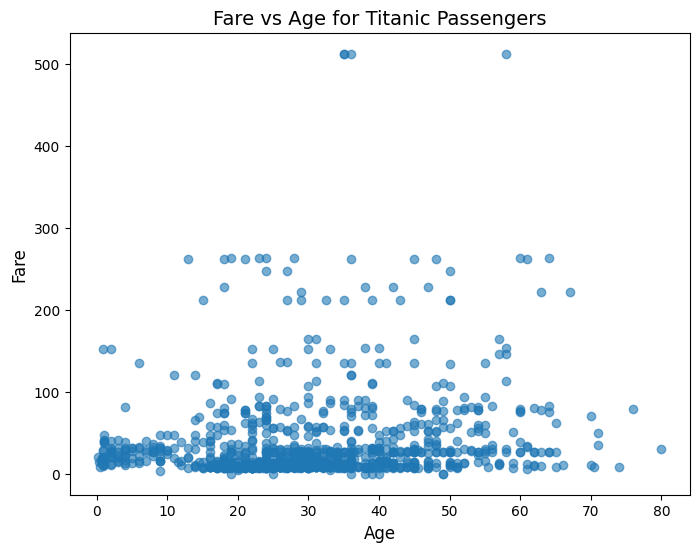

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(titanic_df["age"], titanic_df["fare"], alpha=0.6)

plt.xlabel("Age", fontsize=12)
plt.ylabel("Fare", fontsize=12)
plt.title("Fare vs Age for Titanic Passengers", fontsize=14)

plt.show()



<br><br>



#### 2.14

Create a bar chart of `embarked` values. 

> Make sure to name the axes and give a title to your plot. 

<div class="alert alert-warning">

Your solution_2.14
    
</div>


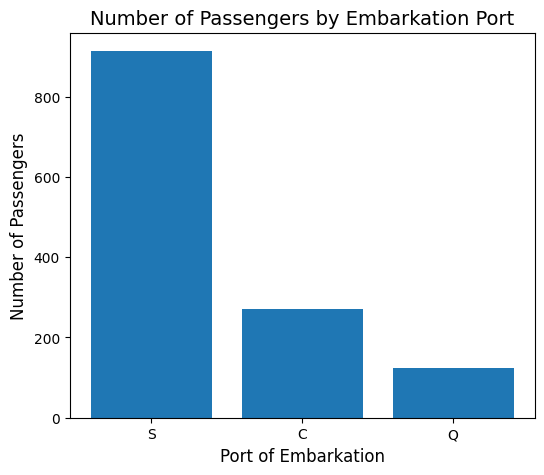

In [21]:
embarked_counts = titanic_df["embarked"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(embarked_counts.index, embarked_counts.values)

plt.xlabel("Port of Embarkation", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.title("Number of Passengers by Embarkation Port", fontsize=14)

plt.show()



<br><br><br><br>

## Exercise 3: Exploring toy user-movie ratings with `NumPy`

In this exercise, you will practice `NumPy` by working with a toy user–item ratings matrix. Each row represents a user, each column represents a movie, and entries are ratings from 1–5. Missing ratings are represented by `np.nan`.

In [22]:
import numpy as np

users = ["Tim", "Jamie", "Carol", "David", "Eva"]
movies = ["Inception", "Frozen", "Titanic", "Avengers", "Toy Story", "Joker"]

R = np.array([
    [5, 3, np.nan, 1, np.nan, 2],   # Tim
    [3, np.nan, 2, 1, 2, np.nan],   # Jamie
    [np.nan, 5, 4, 2, np.nan, 3],   # Carol
    [4, 1, np.nan, np.nan, 3, 2],   # David
    [4, np.nan, 5, 4, 5, np.nan]    # Eva
], dtype=float)

print("Users:", users)
print("Movies:", movies)
print(R)


Users: ['Tim', 'Jamie', 'Carol', 'David', 'Eva']
Movies: ['Inception', 'Frozen', 'Titanic', 'Avengers', 'Toy Story', 'Joker']
[[ 5.  3. nan  1. nan  2.]
 [ 3. nan  2.  1.  2. nan]
 [nan  5.  4.  2. nan  3.]
 [ 4.  1. nan nan  3.  2.]
 [ 4. nan  5.  4.  5. nan]]


The global average rating across all ratings (ignoring missing values) can be computed as: 

In [23]:
np.nanmean(R)

np.float64(3.05)

<br><br>



### 3.1 User preferences

- Compute the average rating given by each user.
- Who is the most generous rater?
- Who is the harshest critic?

<div class="alert alert-warning">

Your solution_3.1
    
</div>


In [24]:
avg_user_ratings = np.nanmean(R, axis=1)
avg_user_ratings

array([2.75, 2.  , 3.5 , 2.5 , 4.5 ])

In [25]:
most_generous_user = users[np.nanargmax(avg_user_ratings)]
harshest_critic = users[np.nanargmin(avg_user_ratings)]

In [26]:
print("Most generous rater: ", most_generous_user)
print("Harshest critic: ", harshest_critic)

Most generous rater:  Eva
Harshest critic:  Jamie




<br><br>



### 3.2 Movie popularity

- Compute the average rating for each movie.
- Which movie is the most loved?
- Which movie is the least loved?

<div class="alert alert-warning">

Your solution_3.2
    
</div>


In [27]:
avg_movie_ratings =    np.nanmean(R, axis=0)
avg_movie_ratings

array([4.        , 3.        , 3.66666667, 2.        , 3.33333333,
       2.33333333])

In [28]:
most_loved_movie =  movies[np.nanargmax(avg_movie_ratings)]
least_loved_movie =  movies[np.nanargmin(avg_movie_ratings)]

In [29]:
print("Most loved movie: ", most_loved_movie)
print("Least loved movie: ", least_loved_movie)

Most loved movie:  Inception
Least loved movie:  Avengers




<br><br>



### 3.3 Filling missing values

- Create a new matrix `R_filled` where missing ratings (`np.nan`) are replaced with the movie average for that column.
- After filling, what rating would you predict for Jamie on Frozen?

_Hint: you can use `np.where(condition, A, B)` or specifically np.where(np.isnan(R), …) to selectively replace values._

<div class="alert alert-warning">

Your solution_3.3
    
</div>


In [30]:
R_filled = np.where(np.isnan(R), avg_movie_ratings, R)
R_filled

array([[5.        , 3.        , 3.66666667, 1.        , 3.33333333,
        2.        ],
       [3.        , 3.        , 2.        , 1.        , 2.        ,
        2.33333333],
       [4.        , 5.        , 4.        , 2.        , 3.33333333,
        3.        ],
       [4.        , 1.        , 3.66666667, 2.        , 3.        ,
        2.        ],
       [4.        , 3.        , 5.        , 4.        , 5.        ,
        2.33333333]])

In [31]:
jamie_frozen_rating = R_filled[1, 1]
print("Jamie's rating on Frozen:", jamie_frozen_rating)

Jamie's rating on Frozen: 3.0




<br><br><br><br>


Well done!!

![](img/eva-well-done.png)